# Influential Outlier Metric for PISA data

In [1]:
%pip install pyreadstat optuna pingouin normflows

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 26.8 MB/s eta 0:00:00
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size=87352 sha256=fb9589c928fc2c111343afe81a786282d32be7933ab9a8988a805364ba3cc7cf
  Stored in directory: /root/.cache/pip/wheels/a4/8a/16/ee8092d127718f6c6ac8396704ebed7637d2ae56417700e06c
Successfully built normflows


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("LocalSpark")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


from joblib import Parallel, delayed
from tqdm import tqdm, trange

from scipy import stats

import optuna

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
import xgboost as xgb
from xgboost.callback import EarlyStopping

from iom import InfluentialOutlierMetric

## MEGB

In [7]:
class MEGB_CPU:
    def __init__(
        self,
        xgb_params=None,
        max_iter=6,
        tol=1e-4,
        random_state=42,
    ):
        xgb_params = dict(xgb_params or {})

        xgb_params.setdefault("learning_rate", 0.05)
        xgb_params.setdefault("max_depth", 6)
        xgb_params.setdefault("subsample", 0.9)
        xgb_params.setdefault("colsample_bytree", 0.9)
        xgb_params.setdefault("objective", "reg:squarederror")

        # CPU settings
        xgb_params.setdefault("tree_method", "hist")
        xgb_params.setdefault("device", "cpu")

        xgb_params.setdefault("nthread", -1)
        xgb_params.setdefault("verbosity", 0)
        xgb_params.setdefault("seed", random_state)

        self.xgb_params = xgb_params
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.booster = None
        self.bhat = None
        self.group_map = None
        self.sigma2_hat = None

    def fit(self, X, y, groups):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        groups = np.asarray(groups)

        unique_groups, group_idx = np.unique(
            groups,
            return_inverse=True,
        )
        counts = np.bincount(group_idx).astype(np.float32)

        tr_idx, val_idx = train_test_split(
            np.arange(len(y)),
            test_size=0.2,
            random_state=self.random_state,
        )

        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
        dvalid = xgb.DMatrix(X[val_idx], label=y[val_idx])
        dfull = xgb.DMatrix(X)

        bhat = np.zeros(len(unique_groups), dtype=np.float32)
        mu_hat = np.zeros_like(y)
        sigma2 = np.var(y)

        booster = None

        for _ in range(self.max_iter):
            # Fixed-effects update
            dtrain.set_label(
                y[tr_idx] - bhat[group_idx[tr_idx]]
            )
            dvalid.set_label(
                y[val_idx] - bhat[group_idx[val_idx]]
            )

            booster = xgb.train(
                params=self.xgb_params,
                dtrain=dtrain,
                num_boost_round=500,
                evals=[(dvalid, "val")],
                early_stopping_rounds=20,
                xgb_model=booster,
                verbose_eval=False,
            )

            mu_hat[:] = booster.predict(dfull)

            # Random-intercept update
            residuals = y - mu_hat
            bhat_new = (
                np.bincount(group_idx, weights=residuals)
                / counts
            ).astype(np.float32)

            # Residual-variance update
            full_residuals = (
                y - mu_hat - bhat_new[group_idx]
            )
            sigma2_new = np.mean(full_residuals**2)

            converged = (
                abs(sigma2_new - sigma2)
                < self.tol * (sigma2 + 1e-12)
            )

            bhat = bhat_new
            sigma2 = sigma2_new

            if converged:
                break

        self.booster = booster
        self.bhat = bhat
        self.group_map = {
            group: index
            for index, group in enumerate(unique_groups)
        }
        self.sigma2_hat = sigma2

        return self

    def predict(self, X, groups):
        if self.booster is None:
            raise RuntimeError(
                "The model must be fitted before calling predict()."
            )

        X = np.asarray(X, dtype=np.float32)
        groups = np.asarray(groups)

        dmat = xgb.DMatrix(X)
        y_fixed = self.booster.predict(dmat)

        group_idx = np.array(
            [self.group_map.get(group, -1) for group in groups],
            dtype=int,
        )

        random_effects = np.zeros(
            len(groups),
            dtype=np.float32,
        )
        known_groups = group_idx >= 0
        random_effects[known_groups] = self.bhat[
            group_idx[known_groups]
        ]

        return y_fixed + random_effects

In [8]:
import random
import warnings

def stratified_by_group_kfold_megb_loss_cpu(
    trial,
    MEGBClass,
    xgb_params,
    max_iter,
    tol,
    X,
    y,
    groups,
    splits,
    seed,
):
    rmse_list = []

    for fold_id, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        groups_tr = groups[train_idx]
        groups_te = groups[test_idx]

        fold_seed = seed + fold_id

        # Include the fold seed in the underlying XGBoost parameters.
        fold_xgb_params = {
            **xgb_params,
            "random_state": fold_seed,
            "seed": fold_seed,
        }

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = MEGBClass(
                xgb_params=fold_xgb_params,
                max_iter=max_iter,
                tol=tol,
                random_state=fold_seed,
            )

            model.fit(X_tr, y_tr, groups_tr)
            preds = model.predict(X_te, groups_te)

        rmse = np.sqrt(mean_squared_error(y_te, preds))
        rmse_list.append(rmse)

        trial.report(rmse, step=fold_id)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rmse_list))


def objective_megb_cpu(
    trial,
    X,
    y,
    groups,
    splits,
    seed,
):
    xgb_params = {
        # Reproducible CPU settings
        "device": "cpu",
        "tree_method": "hist",
        "nthread": 1,
        "random_state": seed,
        "seed": seed,

        # Tuned parameters
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.02, 0.2
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 8
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 2.0
        ),
    }

    max_iter = trial.suggest_int("max_iter", 3, 8)
    tol = trial.suggest_float(
        "tol",
        1e-5,
        1e-3,
        log=True,
    )

    return stratified_by_group_kfold_megb_loss_cpu(
        trial=trial,
        MEGBClass=MEGB_CPU,
        xgb_params=xgb_params,
        max_iter=max_iter,
        tol=tol,
        X=X,
        y=y,
        groups=groups,
        splits=splits,
        seed=seed,
    )


def tune_megb_cpu(
    X,
    y,
    groups,
    n_trials=50,
    n_jobs=1,
    seed=42,
):
    # Seed process-level random number generators.
    random.seed(seed)
    np.random.seed(seed)

    X_np = np.asarray(X)
    y_np = np.asarray(y)
    groups_np = np.asarray(groups)

    # Generate the same folds on every run.
    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=seed,
    )

    splits = list(skf.split(X_np, groups_np))

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=2,
        ),
    )

    study.optimize(
        lambda trial: objective_megb_cpu(
            trial=trial,
            X=X_np,
            y=y_np,
            groups=groups_np,
            splits=splits,
            seed=seed,
        ),
        n_trials=n_trials,
        n_jobs=n_jobs,
        show_progress_bar=True,
    )

    return study.best_params

## Small model

In [6]:
Data = spark.read.parquet("/content/drive/My Drive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data = Data.set_index('CNTSTUID')

In [12]:
X = Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH'])
y = Data['PV1MATH']
groups = Data['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [13]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=32, seed=42)

[I 2026-09-15 18:21:12,632] A new study created in memory with name: no-name-bf1f49ca-6839-4c1b-bb1d-54ca39c607c7


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-09-15 18:21:14,041] Trial 0 finished with value: 74.56298055921594 and parameters: {'learning_rate': 0.08741722139252527, 'max_depth': 8, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.3119890406724053, 'max_iter': 3, 'tol': 0.0005399484409787432}. Best is trial 0 with value: 74.56298055921594.
[I 2026-09-15 18:21:15,238] Trial 1 finished with value: 73.17007701788732 and parameters: {'learning_rate': 0.1282007021137776, 'max_depth': 7, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 0.4246782213565523, 'max_iter': 4, 'tol': 2.3270677083837777e-05}. Best is trial 1 with value: 73.17007701788732.
[I 2026-09-15 18:21:16,392] Trial 2 finished with value: 73.07197617832976 and parameters: {'learning_rate': 0.0747636037327168, 'max_depth': 6, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'min_child_weight': 7, 'gamma': 0.27898772130408367, 'ma

In [14]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [15]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 71.2644797470772


### Student level

In [16]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']).values, dtype=np.float32)),
    pred_contribs=True
)

In [17]:
resid = Data['PV1MATH'] - best_model.predict(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']), Data['CNTSCHID'])

<Axes: ylabel='Count'>

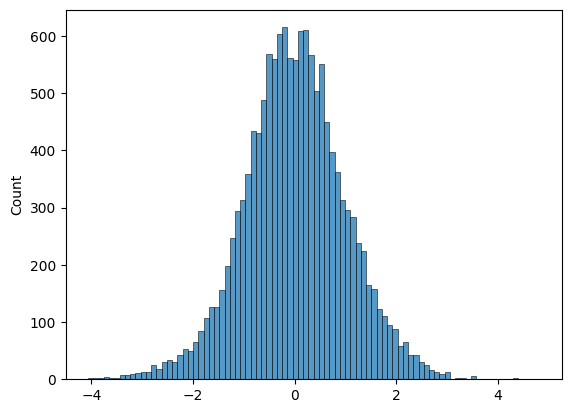

In [18]:
sns.histplot(StandardScaler().fit_transform(resid.values.reshape(-1,1)).ravel())

<Axes: ylabel='Count'>

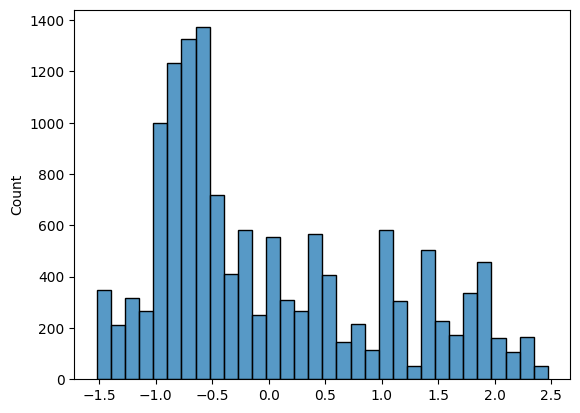

In [19]:
sns.histplot(StandardScaler().fit_transform(shap_values[:,:1]).ravel())

In [20]:
iom = InfluentialOutlierMetric()

In [28]:
results_iom = iom.find_best_lambda(
    StandardScaler().fit_transform(shap_values[:,:1]),
    lambdas = np.exp(np.linspace(-15, 0, 10)),
    K=13,
    hidden=13,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=2.5,
    num_bins=10,
    torch_seed=42
)

lambda: 3.059023205018258e-07
cuda


Normalizing flow: 100%|██████████| 1000/1000 [06:04<00:00,  2.75it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0762

[1b] Stouffer combined normality p-value
     z = 1.4313
     p = 0.07618
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0000
    CvM p-value: 0.0555
    Q mean:      1.0064  expected approx d=1
    Q max:       8.1155
    min tail p:  0.004389
lambda: 1.6195967923126097e-06
cuda


Normalizing flow: 100%|██████████| 1000/1000 [06:01<00:00,  2.77it/s]

--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0067

[1b] Stouffer combined normality p-value
     z = 2.4723
     p = 0.006713
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0000
    CvM p-value: 0.0188
    Q mean:      0.9704  expected approx d=1
    Q max:       7.9293
    min tail p:  0.004864
Final lambda: 0.0000
Mean test distance: 0.1031
Final weights: [np.float32(1.0)]
Final means: [array([0.074], dtype=float32)]
Final scales: [array([0.8507], dtype=float32)]


In [29]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.57it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.2083

[1b] Stouffer combined normality p-value
     z = 0.8123
     p = 0.2083
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5852
    CvM p-value: 0.5235
    Q mean:      1.0189  expected approx d=1
    Q max:       21.6256
    min tail p:  3.314e-06
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.48it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.1466

[1b] Stouffer combined normality p-value
     z = 1.0513
     p = 0.1466
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6278
    CvM p-value: 0.5701
    Q mean:      1.0190  expected approx d=1
    Q max:       21.7074
    min tail p:  3.176e-06
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.55it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.1056

[1b] Stouffer combined normality p-value
     z = 1.2500
     p = 0.1056
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6328
    CvM p-value: 0.6427
    Q mean:      1.0186  expected approx d=1
    Q max:       21.7769
    min tail p:  3.063e-06
lambda: 0.025561533206507392
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.58it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0450

[1b] Stouffer combined normality p-value
     z = 1.6949
     p = 0.04505
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5367
    CvM p-value: 0.6936
    Q mean:      1.0182  expected approx d=1
    Q max:       21.9206
    min tail p:  2.842e-06
Final lambda: 0.0131
Mean test distance: 0.0151
Final weights: [np.float32(1.0)]
Final means: [array([-0.0952], dtype=float32)]
Final scales: [array([1.0519], dtype=float32)]


In [30]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,0.827560
1,0.009918
2,0.027623
3,0.994992
4,0.160885
...,...
13721,0.005114
13722,0.006719
13723,0.766690
13724,0.000334


In [31]:
Data['IOM_i'] = iom.IOM_.values
Data['SHAP_z'] = results_iom['chi_z']
Data['resid_z'] = results_iom_resid['chi_z']

In [33]:
iom.find_threshold(p=1)

Threshold at 0.05: 4.761
Threshold at 0.01: 12.990


[4.760901368628315, 12.990352807262584]

In [32]:
Data[Data['IOM_i'] > 12.990352807262584].sort_values(by='IOM_i', ascending=False).shape

(137, 7)

In [83]:
Data[Data['IOM_i'] > 12.990352807262584].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,
70202246.0,SGP,70200047.0,364.475,1.0895,87.393142,6.163805,14.178441
70203507.0,SGP,70200104.0,454.227,1.3628,62.884630,7.978248,7.882010
70204980.0,SGP,70200099.0,385.830,1.3463,45.106182,7.978248,5.653645
60800985.0,PHL,60800086.0,523.781,-0.8900,44.912111,5.526395,8.126838
60806859.0,PHL,60800039.0,498.450,-0.7296,44.349990,6.462263,6.862920


### School level

In [33]:
Data_group = pd.concat([pd.Series(best_model.group_map.keys()), pd.Series(best_model.bhat)], axis=1)
Data_group.columns = ['CNTSCHID', 'bhat']

In [34]:
Data_group_final = Data_group.merge(Data[['CNTSCHID', 'CNT']], on='CNTSCHID', how='left').drop_duplicates()
Data_group_final = Data_group_final.rename(columns={'CNT': 'Country'})

Text(0.5, 0, '')

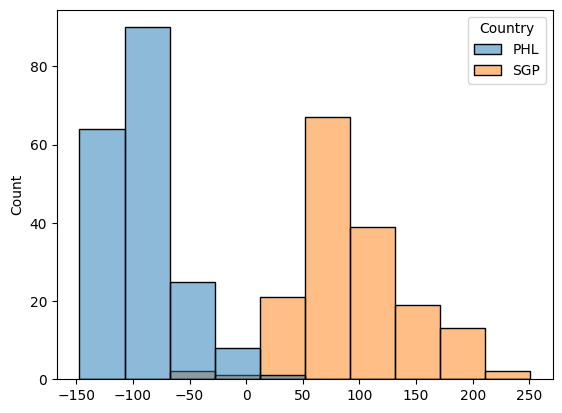

In [35]:
sns.histplot(Data_group_final, x='bhat', hue='Country')
plt.xlabel(None)

In [36]:
iom_sch = InfluentialOutlierMetric()

In [37]:
results_iom_sch_bm = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[-100, 100],
    scale=[50, 50],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:26<00:00, 19.22it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 180  test: Jarque-Bera  pvalue: 0.2530
    mode: 1  n: 172  test: Jarque-Bera  pvalue: 0.4476

[1b] Stouffer combined normality p-value
     z = 0.5634
     p = 0.2866
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.8686
    CvM p-value: 0.9542
    Q mean:      0.9131  expected approx d=1
    Q max:       7.7538
    min tail p:  0.00536
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.35it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 180  test: Jarque-Bera  pvalue: 0.2528
    mode: 1  n: 172  test: Jarque-Bera  pvalue: 0.4637

[1b] Stouffer combined normality p-value
     z = 0.5352
     p = 0.2963
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.8393
    CvM p-value: 0.9403
    Q mean:      0.9107  expected approx d=1
    Q max:       7.7965
    min tail p:  0.005235
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=352, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2770
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.3096

[1b] Stouffer combined normality p-value
     z = 0.7699
     p = 0.2207
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.6070
    CvM p-value: 0.4963
    Q mean:      0.8778  expected approx d=1
    Q max:       8.6102
    min tail p:  0.003343
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.27it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 186  test: Jarque-Bera  pvalue: 0.3100
    mode: 1  n: 166  test: Jarque-Bera  pvalue: 0.1874

[1b] Stouffer combined normality p-value
     z = 0.9783
     p = 0.164
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.2204
    CvM p-value: 0.2169
    Q mean:      0.8571  expected approx d=1
    Q max:       9.1214
    min tail p:  0.002526
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.46it/s]

--- Whitened mode-normality diagnostics (n=352, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 186  test: Jarque-Bera  pvalue: 0.2942
    mode: 1  n: 166  test: Jarque-Bera  pvalue: 0.0946

[1b] Stouffer combined normality p-value
     z = 1.3112
     p = 0.0949
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.0632
    CvM p-value: 0.0477
    Q mean:      0.8222  expected approx d=1
    Q max:       9.7898
    min tail p:  0.001755
Final lambda: 0.1889
Mean test distance: 168.7711
Final weights: [np.float32(0.504), np.float32(0.496)]
Final means: [array([-99.7819], dtype=float32), array([99.9701], dtype=float32)]
Final scales: [array([44.8083], dtype=float32), array([50.3132], dtype=float32)]


In [38]:
results_iom_sch_um = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[100],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.28it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.2823

[1b] Stouffer combined normality p-value
     z = 0.5759
     p = 0.2823
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7218
    CvM p-value: 0.5774
    Q mean:      1.0027  expected approx d=1
    Q max:       8.0257
    min tail p:  0.004612
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:26<00:00, 19.19it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.2834

[1b] Stouffer combined normality p-value
     z = 0.5728
     p = 0.2834
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6794
    CvM p-value: 0.5632
    Q mean:      1.0008  expected approx d=1
    Q max:       8.0798
    min tail p:  0.004476
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=352, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.1526

[1b] Stouffer combined normality p-value
     z = 1.0253
     p = 0.1526
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.3907
    CvM p-value: 0.2528
    Q mean:      0.9950  expected approx d=1
    Q max:       8.2521
    min tail p:  0.004071
lambda: 0.09697196786440505
cuda


Normalizing flow: 100%|██████████| 500/500 [00:26<00:00, 18.55it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.0686

[1b] Stouffer combined normality p-value
     z = 1.4863
     p = 0.0686
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1750
    CvM p-value: 0.1147
    Q mean:      0.9825  expected approx d=1
    Q max:       8.5181
    min tail p:  0.003516
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:27<00:00, 18.17it/s]

--- Whitened mode-normality diagnostics (n=352, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.0300

[1b] Stouffer combined normality p-value
     z = 1.8811
     p = 0.02998
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0737
    CvM p-value: 0.0357
    Q mean:      0.9806  expected approx d=1
    Q max:       8.7754
    min tail p:  0.003053
Final lambda: 0.0970
Mean test distance: 849.5847
Final weights: [np.float32(1.0)]
Final means: [array([0.0381], dtype=float32)]
Final scales: [array([86.3044], dtype=float32)]


In [39]:
iom_sch.select_flow_by_transport_modes([results_iom_sch_um, results_iom_sch_bm])

{'selected_index': 1,
 'table': [{'index': 0,
   'M': 849.5846557617188,
   'n_modes': 1,
   'K_m': 2,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(850.2778029422786)},
  {'index': 1,
   'M': 168.77113342285156,
   'n_modes': 2,
   'K_m': 5,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(170.50400137425143)}]}

In [40]:
Data_group_final['bhat_z'] = results_iom_sch_bm['chi_z']

In [41]:
stats.chi2.ppf(0.99, df=1)

np.float64(6.6348966010212145)

In [42]:
Data_group_final[Data_group_final['bhat_z'] > stats.chi2.ppf(0.99, df=1)].sort_values(by='bhat_z', ascending=False)

,CNTSCHID,bhat,Country,bhat_z
7259,70200003.0,250.957962,SGP,9.121380
7167,70200001.0,236.214981,SGP,7.487024


## Full model

In [9]:
Data = spark.read.parquet("/content/drive/MyDrive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS", "MATHEFF", "MATHPERS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data['CNTSCHID'] = Data['CNTSCHID'].astype(str)

In [10]:
Data['CNT'] = pd.get_dummies(Data['CNT'], drop_first=True).astype(int) #PHL = 0

In [11]:
Data_sch = pd.read_spss("/content/drive/MyDrive/PISA/CY08MSP_SCH_QQQ.SAV")[["CNTSCHID", "PROPMATH"]].dropna()
Data_sch['CNTSCHID'] = Data_sch['CNTSCHID'].astype(str)

In [12]:
Data_final = Data.merge(Data_sch, on="CNTSCHID", how="left").dropna()
Data_final = Data_final.set_index('CNTSTUID')

In [13]:
Data_final

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH
CNTSTUID,,,,,,,
60806165.0,0,60800182.0,370.444,0.2782,-1.8037,-0.7105,0.1273
60806166.0,0,60800024.0,314.718,-2.6258,0.1777,-0.4530,0.1087
60806167.0,0,60800142.0,268.274,-0.9840,-1.2857,-1.1216,0.1382
60806170.0,0,60800150.0,316.133,-2.3435,-0.2575,-0.6146,0.1429
60806171.0,0,60800009.0,298.137,0.3207,-0.5574,-0.3073,0.1304
...,...,...,...,...,...,...,...
60806158.0,0,60800119.0,392.198,-1.8552,2.2512,0.7827,1.0000
60806160.0,0,60800113.0,395.818,0.2381,-0.0559,0.1930,0.1124
60806161.0,0,60800022.0,406.132,-1.3717,-3.4876,-0.7219,0.1250


In [14]:
X = Data_final.drop(columns=['CNTSCHID', 'PV1MATH'])
y = Data_final['PV1MATH']
groups = Data_final['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [16]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=32, seed=42)

[I 2026-09-16 20:11:40,677] A new study created in memory with name: no-name-b7c2597d-f78a-4f4d-9064-1a6be14b9513


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-09-16 20:11:41,979] Trial 0 finished with value: 68.9209014282739 and parameters: {'learning_rate': 0.08741722139252527, 'max_depth': 8, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.3119890406724053, 'max_iter': 3, 'tol': 0.0005399484409787432}. Best is trial 0 with value: 68.9209014282739.
[I 2026-09-16 20:11:43,080] Trial 1 finished with value: 69.46644997344377 and parameters: {'learning_rate': 0.1282007021137776, 'max_depth': 7, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 0.4246782213565523, 'max_iter': 4, 'tol': 2.3270677083837777e-05}. Best is trial 0 with value: 68.9209014282739.
[I 2026-09-16 20:11:44,295] Trial 2 finished with value: 67.46492051860831 and parameters: {'learning_rate': 0.0747636037327168, 'max_depth': 6, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'min_child_weight': 7, 'gamma': 0.27898772130408367, 'max_i

In [17]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [18]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 64.07791112040482


### Student level

In [19]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(Data_final.drop(columns=['CNTSCHID', 'PV1MATH']).values, dtype=np.float32)),
    pred_contribs=True
)

In [20]:
shap_values = pd.DataFrame(shap_values)
shap_values.columns = ['CNT', 'ESCS',"MATHEFF", "MATHPERS", "PROPMATH", 'Intercept']

In [21]:
resid = Data_final['PV1MATH'] - best_model.predict(Data_final.drop(columns=['CNTSCHID', 'PV1MATH']), Data_final['CNTSCHID'])

<Axes: ylabel='Count'>

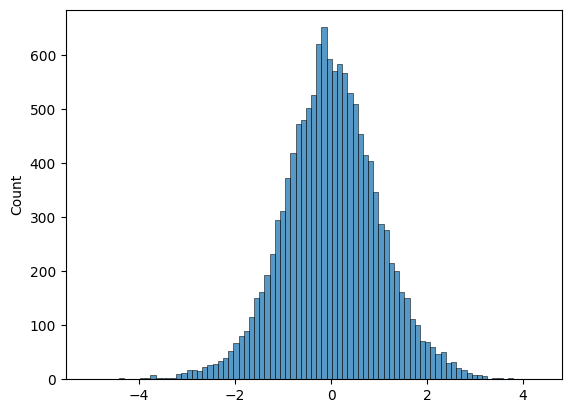

In [22]:
sns.histplot(StandardScaler().fit_transform(resid.values.reshape(-1,1)).ravel())

<Axes: ylabel='Count'>

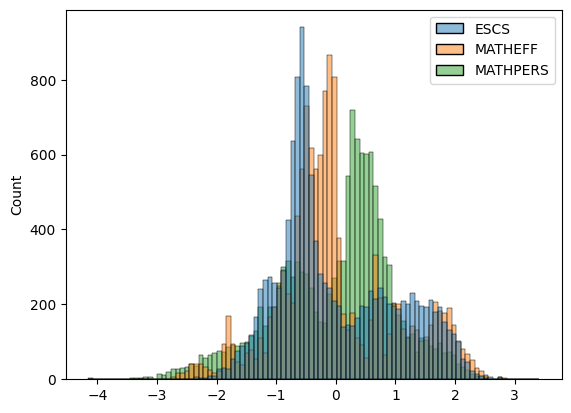

In [23]:
shap_values_stu_s = pd.DataFrame(StandardScaler().fit_transform(shap_values[['ESCS', "MATHEFF", "MATHPERS"]]), columns= ['ESCS', "MATHEFF", "MATHPERS"])
sns.histplot(shap_values_stu_s)

In [24]:
iom = InfluentialOutlierMetric()

In [ ]:
results_iom = iom.find_best_lambda(
    shap_values_stu_s.values,
    context=Data_final['CNT'].values,
    K=12,
    hidden=12,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=4,
    num_bins=13,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [07:19<00:00,  2.27it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.4724

[1b] Stouffer combined normality p-value
     z = 0.0692
     p = 0.4724
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5442
    CvM p-value: 0.7714
    Q mean:      3.0087  expected approx d=3
    Q max:       22.2778
    min tail p:  5.71e-05
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [07:23<00:00,  2.26it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.3075

[1b] Stouffer combined normality p-value
     z = 0.5029
     p = 0.3075
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.2781
    CvM p-value: 0.1804
    Q mean:      2.9817  expected approx d=3
    Q max:       26.5104
    min tail p:  7.456e-06
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 1000/1000 [07:27<00:00,  2.24it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.2553

[1b] Stouffer combined normality p-value
     z = 0.6578
     p = 0.2553
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0198
    CvM p-value: 0.0109
    Q mean:      2.9544  expected approx d=3
    Q max:       30.1982
    min tail p:  1.254e-06
Final lambda: 0.0067
Mean test distance: 0.8964
Final weights: [np.float32(1.0)]
Final means: [array([-0.0342,  0.0027, -0.0577], dtype=float32)]
Final scales: [array([0.9063, 0.8642, 0.8917], dtype=float32)]


In [34]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    context=Data_final['CNT'].values,
    lambdas=np.exp(np.linspace(-15, 0, 10)), 
    K=12,
    hidden=12,
    layers=3,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=5.1,
    num_bins=8,
    torch_seed=42
)

lambda: 3.059023205018258e-07
cuda


Normalizing flow: 100%|██████████| 500/500 [03:20<00:00,  2.49it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.8717

[1b] Stouffer combined normality p-value
     z = -1.1347
     p = 0.8717
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0518
    CvM p-value: 0.0597
    Q mean:      1.0282  expected approx d=1
    Q max:       23.8883
    min tail p:  1.021e-06
lambda: 1.6195967923126097e-06
cuda


Normalizing flow: 100%|██████████| 500/500 [03:20<00:00,  2.49it/s]

--- Whitened mode-normality diagnostics (n=12955, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.9424

[1b] Stouffer combined normality p-value
     z = -1.5755
     p = 0.9424
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0327
    CvM p-value: 0.0305
    Q mean:      1.0302  expected approx d=1
    Q max:       23.8891
    min tail p:  1.02e-06
Final lambda: 0.0000
Mean test distance: 0.0374
Final weights: [np.float32(1.0)]
Final means: [array([-0.0067], dtype=float32)]
Final scales: [array([1.0335], dtype=float32)]


In [35]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,5.640778
1,0.551126
2,3.398449
3,0.041096
4,1.173244
...,...
12950,1.002860
12951,0.343397
12952,5.837127
12953,0.851335


In [36]:
Data_final['IOM_i'] = iom.IOM_.values
Data_final['SHAP_z'] = results_iom['chi_z']
Data_final['resid_z'] = results_iom_resid['chi_z']

In [37]:
iom.find_threshold(p=3)

Threshold at 0.05: 12.984
Threshold at 0.01: 28.695


[12.9843375948851, 28.695046476162922]

In [38]:
Data_final[Data_final['IOM_i'] > 28.695].sort_values(by='IOM_i', ascending=False)

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,
70203381.0,1,70200076.0,943.041,1.1072,2.1839,0.9681,0.1244,126.902762,9.166808,13.843724
70200825.0,1,70200133.0,722.039,1.2542,2.1030,2.7480,0.1818,108.668098,22.925096,4.740137
60804623.0,0,60800116.0,263.326,-0.1142,1.2588,-0.1875,0.1622,98.158672,12.084670,8.122578
70206780.0,1,70200061.0,747.171,0.9026,-1.3069,0.5729,0.1218,91.532218,14.543813,6.293550
60806855.0,0,60800074.0,200.888,-3.1790,-0.5502,1.1423,0.1545,87.018140,8.536968,10.193097
...,...,...,...,...,...,...,...,...,...,...
60805248.0,0,60800036.0,470.265,0.1847,-2.2549,-0.3033,0.1600,29.130073,5.861344,4.969863
70206029.0,1,70200073.0,544.886,1.4004,2.2345,1.5008,0.0994,29.019273,6.811960,4.260047
60802097.0,0,60800131.0,515.418,-1.8082,0.9105,0.3861,0.1158,28.871547,5.319900,5.427085


In [39]:
Data_final[Data_final['IOM_i'] > 28.695].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,
70203381.0,1,70200076.0,943.041,1.1072,2.1839,0.9681,0.1244,126.902762,9.166808,13.843724
70200825.0,1,70200133.0,722.039,1.2542,2.1030,2.7480,0.1818,108.668098,22.925096,4.740137
60804623.0,0,60800116.0,263.326,-0.1142,1.2588,-0.1875,0.1622,98.158672,12.084670,8.122578
70206780.0,1,70200061.0,747.171,0.9026,-1.3069,0.5729,0.1218,91.532218,14.543813,6.293550
60806855.0,0,60800074.0,200.888,-3.1790,-0.5502,1.1423,0.1545,87.018140,8.536968,10.193097


### School level

<Axes: ylabel='Count'>

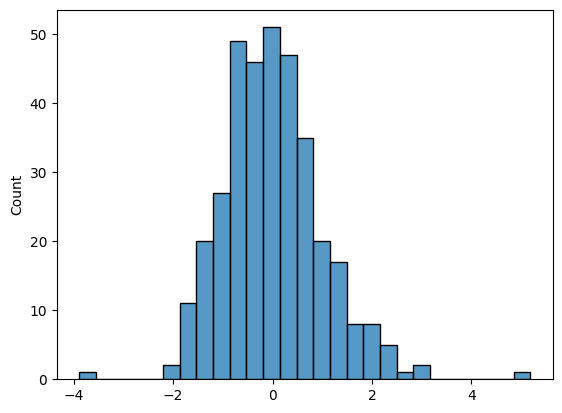

In [40]:
sns.histplot(StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)).ravel())

In [41]:
Data_final['PROPMATH'] = pd.to_numeric(Data_final['PROPMATH'])

In [42]:
Data_final_sch = (
    Data_final
    .groupby("CNTSCHID", as_index=False)
    .agg({
        **{
            col: "mean"
            for col in Data_final.select_dtypes(include="number").columns
            if col != "CNTSCHID"
        },
        "CNT": "first",
    })
)[['CNT', 'CNTSCHID', 'PROPMATH', 'PV1MATH']]

In [43]:
shap_values['CNTSCHID'] = Data_final['CNTSCHID'].values
shap_sch = shap_values[["PROPMATH", 'CNTSCHID']].groupby("CNTSCHID").mean().reset_index()

In [44]:
shap_sch_final = shap_sch.merge(Data_final_sch[['CNT', 'CNTSCHID']], how='left', on='CNTSCHID')

<Axes: ylabel='Count'>

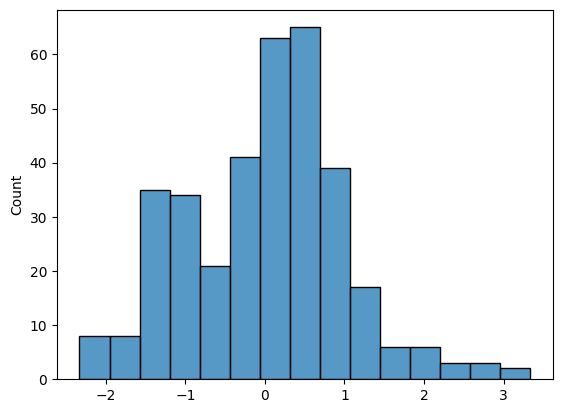

In [55]:
shap_sch_s = pd.DataFrame(StandardScaler().fit_transform(shap_sch_final[['PROPMATH']].values), columns = ["PROPMATH"])
sns.histplot(shap_sch_s.values.ravel())

In [46]:
iom_sch = InfluentialOutlierMetric()

In [47]:
results_iom_sch = iom_sch.find_best_lambda(
    shap_sch_s.values,
    context = shap_sch_final[['CNT']].values,
    lambdas=[10**10],
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 10000000000
cuda


Normalizing flow: 100%|██████████| 500/500 [00:30<00:00, 16.15it/s]

--- Whitened mode-normality diagnostics (n=351, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.5187

[1b] Stouffer combined normality p-value
     z = -0.0470
     p = 0.5187
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9021
    CvM p-value: 0.7369
    Q mean:      0.9651  expected approx d=1
    Q max:       10.6537
    min tail p:  0.001099
Final lambda: 10000000000.0000
Mean test distance: 0.0000
Final weights: [np.float32(1.0)]
Final means: [array([0.0001], dtype=float32)]
Final scales: [array([1.018], dtype=float32)]


In [48]:
cnt = pd.DataFrame(pd.Series(list(best_model.group_map.keys()),name='CNTSCHID')).merge(Data_final_sch, on='CNTSCHID')['CNT']

In [59]:
results_iom_sch_resid = iom_sch.find_best_lambda(
    StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)),
    context=cnt.values,
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=5.2,
    num_bins=14,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [01:00<00:00,  8.25it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0640

[1b] Stouffer combined normality p-value
     z = 1.5217
     p = 0.06405
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9713
    CvM p-value: 0.9685
    Q mean:      1.0272  expected approx d=1
    Q max:       19.4215
    min tail p:  1.048e-05
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [01:02<00:00,  8.02it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0611

[1b] Stouffer combined normality p-value
     z = 1.5455
     p = 0.06111
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9924
    CvM p-value: 0.9831
    Q mean:      1.0364  expected approx d=1
    Q max:       19.4932
    min tail p:  1.01e-05
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 500/500 [01:00<00:00,  8.28it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0586

[1b] Stouffer combined normality p-value
     z = 1.5671
     p = 0.05855
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9735
    CvM p-value: 0.9725
    Q mean:      1.0360  expected approx d=1
    Q max:       19.6237
    min tail p:  9.429e-06
lambda: 0.025561533206507392
cuda


Normalizing flow: 100%|██████████| 500/500 [01:01<00:00,  8.10it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0407

[1b] Stouffer combined normality p-value
     z = 1.7422
     p = 0.04074
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9316
    CvM p-value: 0.9640
    Q mean:      1.0206  expected approx d=1
    Q max:       19.8990
    min tail p:  8.164e-06
Final lambda: 0.0131
Mean test distance: 0.0877
Final weights: [np.float32(1.0)]
Final means: [array([0.133], dtype=float32)]
Final scales: [array([1.1347], dtype=float32)]


In [60]:
iom_sch.IOM(results_iom_sch, results_iom_sch_resid)

,IOM
0,0.521453
1,0.142802
2,0.015253
3,0.008811
4,0.263973
...,...
346,0.378138
347,0.292294
348,0.055470
349,5.541767


In [61]:
Data_final_sch['IOM_j'] = iom_sch.IOM_.values
Data_final_sch['SHAP_z'] = results_iom_sch['chi_z']
Data_final_sch['resid_z'] = results_iom_sch_resid['chi_z']

In [62]:
iom_test= InfluentialOutlierMetric()
iom_test.find_threshold(p=1)

Threshold at 0.05: 4.761
Threshold at 0.01: 12.990


[4.760901368628315, 12.990352807262584]

In [63]:
Data_final_sch[Data_final_sch['IOM_j'] > 12.990352807262584].sort_values(by=['IOM_j'], ascending=False).head()

,CNT,CNTSCHID,PROPMATH,PV1MATH,IOM_j,SHAP_z,resid_z
188,1,70200001.0,0.1385,728.378907,52.069911,10.459077,4.978442
335,1,70200149.0,0.1963,391.408259,36.349449,4.983618,7.293787
287,1,70200101.0,0.1384,698.928000,26.575002,10.653700,2.494439
190,1,70200003.0,0.2134,742.798806,22.991496,3.485324,6.596659
301,1,70200115.0,0.1965,418.961185,18.651219,4.508165,4.137208
